# Paper figures — the unitary census, $D_{\max}$, and the sector-size distribution

Three final figures, built from the raw sweep records and **meant to be edited**.
Everything the figures draw is either loaded from `results/*.jsonl` or derived in
this notebook; no figure calls `qca_fragmentation.scaling.figure`, so you can
change any of it without touching the package.

| figure | file | what it shows |
|---|---|---|
| **1** | `fig_paper_sectors_obc0.pdf` | number of Krylov sectors vs $N$ — the R2 Fig. 1 content, now for **all sixteen unitary rules** |
| **2** | `fig_paper_dmax_obc0.pdf` | largest sector $D_{\max}$ vs $N$ — same rules, same style |
| **1+2** | `fig_paper_scaling_obc0.pdf` | the two above as panels (a), (b) of one figure |
| **3** | `fig_paper_sizehist_obc0.pdf` | sector-size distribution for W156 and W108 |
| **4** | `fig_paper_frozen_obc0.pdf` | *optional* — frozen-state counts, §8 |

**The claim Figures 1–2 make.** Every rule built only from $I$ and $V$ — sixteen
of them — does exactly one of four things, and the figure is the whole census:

| class | rules | sectors | largest sector |
|---|---|---|---|
| **ergodic** | 51, 57, 99, 147, 153, 195 | $1$ | $2^N$ |
| | 54 | $2$ | $2^N-1$ |
| **polynomial** | 60, 102, 105, 150 | $\Theta(N)$ | $\Theta(2^N/\sqrt N)$ or $2^{N-1}$ |
| **exponential** | 108, 156, 198, 201 | $a^N$, $1<a<2$ | $b^N$, $1<b<2$ |
| **frozen** | 204 | $2^N$ | $1$ |

The two trivial classes are the *bounds* of both panels: nothing can have fewer
than one sector or more than $2^N$, and the ergodic rules and the identity sit
exactly on those lines. Fragmentation is what happens in between.

**Every curve here is an exact integer law, not a fit.** §4 checks each one
against the data at every computed $N$ and raises if any has drifted, so the
annotations on the figures ($F_{N+2}$, $2^{N-1}$, …) are certified rather than
eyeballed.

**On the $N$ ranges.** They used to be very unequal, for a reason that had
nothing to do with the rules: the Tier-1a sweep stops enlarging $N$ once a rule
is classified ergodic (so those seven ended at 13 there), the Tier-1e sweep
covered all 256 rules to $N=16$–17, and only the fragmented rules were pushed to
21–22. §3 merges the two stores, and
`qca_fragmentation.extend_unitary` then closed the remaining gap: for a
*unitary* rule the sector partition is the connected-component structure of the
single-flip graph, which one `uint32` array of $2^N$ entries decides in a
fraction of a second, so **all sixteen rules now run to $N=22$ on the same
grid**. The extension refuses to write a rule's new units until it has
reproduced every unit both sweeps already stored for that rule — three
algorithms, one answer.

The unequal-range machinery is still in place (a track that ends early carries
its $N_{\max}$ in the legend, and no curve is ever extrapolated), because the
ranges can diverge again the moment anyone pushes one rule further.

## Editing this notebook

All the knobs are in §2 — sizes, fonts, palette, which rules appear and how they
are grouped, which $N$ the histograms use, output directory. The drawing code
reads §2 and nothing else, so in the common case you only edit §2 and re-run.

## 1 · Setup

In [1]:
import os, sys, json
from math import log10

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# the package lives in ../code relative to this notebook
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(ROOT, "code"))

from qca_fragmentation import results_io
from qca_fragmentation.core import rules as rules_mod
from qca_fragmentation.scaling import paper_figures as PF

BC = "obc0"          # pbc is held pending caveats -- see NEXT_STEPS.md
print("repo root:", results_io.REPO_ROOT)
print("matplotlib", mpl.__version__)
print("unitary rules:", PF.UNITARY)

repo root: /home/mkmullenbach/Dokumente/Projects/QCA Simulations/Claude Sector Analysis/.claude/worktrees/tier1-analysis
matplotlib 3.9.2
unitary rules: (51, 54, 57, 60, 99, 102, 105, 108, 147, 150, 153, 156, 195, 198, 201, 204)


## 2 · Knobs

Everything adjustable lives here.

**On the palette.** The five hues are the CVD-validated categorical order used
throughout the reports, re-checked over *all* pairs under normal, protan, deutan
and tritan vision. The worst separation is $\Delta E = 7.4$ (W201 green vs W60
blue, tritanopia), which sits in the 6–8 band that is admissible *only* alongside
a secondary encoding. Three are present — distinct markers, a line style that
tracks the class, and a direct law tag at each line end. The amber is at 2.11:1
against the surface, below the 3:1 bar, which is the other reason W108 is
labelled directly instead of being left to the legend.

The two trivial classes are drawn in neutrals rather than a sixth and seventh
hue. That is a claim about the content, not a way of saving colours: an ergodic
rule and the identity are the *frame* of the figure — the $1$ and $2^N$ lines
that everything else lives between — so they should read as reference, and the
saturated hues should belong to the rules that actually fragment.

The histogram encodes $N$, which is an *ordered* quantity, so it uses a one-hue
light→dark ordinal ramp rather than categorical hues.

In [2]:
# ---- output -------------------------------------------------------------
OUT_DIR = os.path.join(ROOT, "figures", "paper")
os.makedirs(OUT_DIR, exist_ok=True)
SAVE_PNG = True          # PNG alongside every PDF, for quick viewing
PNG_DPI  = 300

# ---- page geometry (inches) ---------------------------------------------
COL   = 3.45             # single-column width of a two-column journal page
WIDE  = 7.0              # full-width
H1    = 2.75             # height of one scaling panel
HHIST = 2.35             # height of one histogram row

# ---- type ---------------------------------------------------------------
FS_TICK, FS_LABEL, FS_TITLE, FS_ANNOT, FS_LEGEND = 8, 9, 9.5, 7.5, 7.5

# ---- ink ----------------------------------------------------------------
TEXT, MUTED, GRID = "#0b0b0b", "#8a8a86", "#e6e6e2"
NEUTRAL, DARK     = "#8f8f8a", "#1a1a17"   # the two trivial classes

# ---- the rules, grouped into TRACKS -------------------------------------
# One track = one legend entry.  Rules inside a track share a hue because they
# share a law.  The extra rules are drawn FIRST as large open markers and the
# leading rule filled on top, so where the two coincide you see a dot inside a
# ring and where they part you see a lone ring -- a track that is really two
# curves never passes itself off as one.
#
# All sixteen unitary rules appear.  The six that thermalise give literally the
# same series (§4 checks it), so they are one track; W54 differs from them by a
# single frozen state and gets its own entry rather than being averaged in.
TRACKS = [
    dict(key="156", rules=[156, 198], color="#e34948", marker="o", ls="-",
         label="W156 = W198",  family="exponential"),
    dict(key="108", rules=[108],      color="#eda100", marker="s", ls="-",
         label="W108",         family="exponential"),
    dict(key="201", rules=[201],      color="#006400", marker="^", ls="-",
         label="W201",         family="exponential"),
    dict(key="60",  rules=[60, 102],  color="#2a78d6", marker="D", ls="--",
         label="W60 = W102",   family="polynomial"),
    dict(key="150", rules=[150, 105], color="#4a3aa7", marker="v", ls="--",
         label="W150, W105",   family="polynomial"),
    dict(key="erg", rules=[51, 57, 99, 147, 153, 195],
         color=NEUTRAL, marker="p", ls=":",
         label="ergodic (6 rules)", family="ergodic"),
    dict(key="54",  rules=[54],       color=NEUTRAL, marker="X", ls=":",
         label="W54",          family="ergodic"),
    dict(key="204", rules=[204],      color=DARK,    marker="*", ls=":",
         label="W204 (identity)", family="frozen"),
]

# Short law tags printed at the right-hand end of each curve; {} suppresses them.
LAW_TAG = {
    ("156", "n_recurrent"): r"$F_{N+2}$",
    ("108", "n_recurrent"): r"$\rho^{2N}$",
    ("201", "n_recurrent"): r"$\rho^{2N}$",
    ("60",  "n_recurrent"): r"$N+1$",
    ("150", "n_recurrent"): r"$\sim N/2$",
    ("erg", "n_recurrent"): r"$1$",
    ("54",  "n_recurrent"): r"$2$",
    ("204", "n_recurrent"): r"$2^{N}$",
    ("156", "d_max"):       r"$4^{N/5}$",
    ("108", "d_max"):       r"$F_{N}$",
    ("201", "d_max"):       r"$F_{N+2}$",
    ("60",  "d_max"):       r"$2^{N-1}$",
    ("150", "d_max"):       r"$\binom{N+1}{w^{\ast}}$",
    # The two grey D_max curves differ by one state in four million, i.e. they
    # are one line on this axis, and they run the full N range, so they get one
    # tag between them and the 2^N guide is switched off underneath.
    ("erg", "d_max"):       r"$2^{N}$",
    ("54",  "d_max"):       r"",
    ("204", "d_max"):       r"$1$",
    ("156", "n_frozen"):    r"$\lfloor\frac{N+1}{2}\rfloor+1$",
    ("108", "n_frozen"):    r"$F_{a}F_{b}$",
    ("201", "n_frozen"):    r"$F_{a}F_{b}$",
    ("60",  "n_frozen"):    r"$2$",
    ("150", "n_frozen"):    r"$1,2,1,0$",
    # 0 and 1 sit inside the symlog linear band, where a tag lands on the
    # neighbouring track; the two grey lines are read off the axis instead
    ("erg", "n_frozen"):    r"",
    ("54",  "n_frozen"):    r"",
    ("204", "n_frozen"):    r"$2^{N}$",
}

# Vertical nudges in points, for the few tags that would otherwise collide.
# W108 and W201 are the same sector law shifted by one site, so their curves
# run only a factor 1.75 apart -- close enough that the two tags touch.  In the
# D_max panel W60 ends at N=21 and W150 at N=22, which puts one tag on top of
# the other curve; the ergodic track and W54 end at N=16 with their D_max a
# part in 65536 apart, i.e. on top of each other.
# In the D_max panel at N=22 the top three curves are a factor 2 and a factor
# 1.55 apart, which is 13 and 7 points on a seven-decade axis -- closer than the
# tags are tall, so they have to be prised apart by hand.
TAG_DY = {("108", "n_recurrent"): 5, ("201", "n_recurrent"): -5,
          ("erg", "d_max"): 6, ("60", "d_max"): 2, ("150", "d_max"): -15,
          ("erg", "n_recurrent"): -4, ("54", "n_recurrent"): 4,
          ("150", "n_frozen"): -9}

# The 2^N guide is off in both panels because both are now traced by data over
# the whole range: W204 saturates the sector ceiling and the ergodic rules the
# D_max one.  Switch it back on if you crop the rules.
SHOW_CEILING = {"n_recurrent": False, "d_max": False, "n_frozen": False}
CEILING_LABEL_AT = -1               # index into the ceiling x-grid
CEILING_LABEL_OFFSET = (5, 0)       # points, same convention as a law tag

# All sixteen rules now run to N = 22 (see the header), so nothing triggers
# this -- but the ranges CAN differ, and a track that ends materially short of
# the widest should say so in the legend rather than letting the reader assume
# the curve was cut for space.  The gap keeps the note off a track that merely
# ends one site early.
N_RANGE_IN_LEGEND = True
N_RANGE_LEGEND_GAP = 2

# Which y scale each series gets.  n_frozen NEEDS symlog: the ergodic rules
# have exactly zero frozen states and W105 has none at N = 1 (mod 4), and a log
# axis would silently drop both -- the two most interesting values in the panel.
YSCALE = {"n_recurrent": "log", "d_max": "log", "n_frozen": "symlog"}

LEGEND_KW = {"loc": "upper left", "ncols": 2}
LEGEND_KW_BY_KEY = {"n_frozen": {"loc": "upper left", "ncols": 1}}

N_MAX_PLOT = None        # e.g. 16 to crop the x-range; None = everything
X_PAD_RIGHT = 2.8        # room at the right edge for the law tags

# ---- histogram ----------------------------------------------------------
HIST_RULES = [156, 108]
HIST_NS    = [13, 17, 21]                        # light -> dark
HIST_RAMP  = ["#86b6ef", "#2a78d6", "#104281"]   # one-hue ordinal ramp
# Log-spaced bins.  The sawtooth this leaves in the W156 panel is real, not
# noise: at small s a bin holds only one or two integer sizes, and even sizes
# are far commoner than odd ones.  Raising HIST_BINS sharpens it, lowering it
# averages the parities together.
HIST_BINS  = 22

# ---- optional fourth figure ---------------------------------------------
DRAW_FROZEN_FIGURE = True    # §8; set False to skip

## 3 · Data — and where each rule stops

`PF.unit_series` gives the three integer series per rule; the raw record's
`size_hist` gives the **full** multiset of sector sizes.

Two things about the loading are worth knowing before trusting the figures.

**The two sweeps are merged, and then extended.** Tier-1a (`results/`) ran
Tarjan and *stops enlarging $N$* once a rule is classified ergodic — which is why
the naive loader (`summary.load_series`, which drops ergodic units) returns
nothing at all for seven of the sixteen rules. Tier-1e (`results_tier1e/`) ran
union-find over all 256 rules to $N=16$–17 and carries them in full. For a
unitary rule the weak and strong components coincide, so the two must agree
wherever both ran; `PF.wcc_scc_agreement` checks every overlapping unit and §4
asserts it. `extend_unitary` then filled the tail of every rule out to $N=22$
using the flip reduction, gated on reproducing both sweeps first.

**`sizes_recurrent` is truncated** at 2048 entries once $N\ge16$ (W108:
$N\ge14$), but `size_hist` is not — it carries every class, and
$\sum_s s\,h(s) = 2^N$ exactly. `PF.size_stats` asserts both, so a truncated
field cannot silently become a wrong histogram.

In [3]:
def series(rule):
    """The three scaling series for one rule, as arrays; ergodic units kept.

    `n_frozen` can be None where a record predates the histogram field, so it
    is returned as a float array with NaN rather than being dropped.
    """
    s = PF.unit_series(rule, BC)
    fr = np.array([np.nan if v is None else v for v in s["n_frozen"]], float)
    return {"N": np.array(s["N"]),
            "n_recurrent": np.array(s["n_recurrent"], float),
            "d_max": np.array(s["d_max"], float),
            "n_frozen": fr}


def size_hist(rule, N):
    """{sector size -> how many sectors have it} for one (rule, N).

    Read from `size_hist`, which is complete even where `sizes_recurrent` is
    truncated.  The two asserts are what make that safe to rely on.
    """
    rec = results_io.load_results(rule, BC)[N]
    h = {int(k): int(v) for k, v in rec["size_hist"].items()}
    assert sum(h.values()) == rec["n_recurrent"], (rule, N, "class count")
    assert sum(s * c for s, c in h.items()) == 2 ** N, (rule, N, "mass")
    return h


print(f"{'rule':>5} {'tuple':>6} {'class':>11} {'N range':>9} "
      f"{'n_wcc':>9} {'D_max':>9} {'frozen':>9} {'nD/2^N':>9}")
for row in sorted(PF.census(BC), key=lambda r: (
        ["ergodic", "polynomial", "exponential", "frozen"].index(r["class"]),
        r["rule"])):
    print(f"{row['rule']:>5} {row['tuple']:>6} {row['class']:>11} "
          f"{str(row['N_min']) + '-' + str(row['N_max']):>9} "
          f"{row['n_recurrent']:>9} {row['d_max']:>9} {row['n_frozen']:>9} "
          f"{row['ratio']:>9.4g}")

 rule  tuple       class   N range     n_wcc     D_max    frozen    nD/2^N
   51   VVVV     ergodic      6-22         1   4194304         0         1
   54   IVVV     ergodic      6-22         2   4194303         1         2
   57   VIVV     ergodic      6-22         1   4194304         0         1
   99   VVIV     ergodic      6-22         1   4194304         0         1
  147   VVVI     ergodic      6-22         1   4194304         0         1
  153   VIVI     ergodic      6-22         1   4194304         0         1
  195   VVII     ergodic      6-22         1   4194304         0         1
   60   IIVV  polynomial      6-22        23   2097152         2      11.5
  102   IVIV  polynomial      6-22        23   2097152         2      11.5
  105   VIIV  polynomial      6-22        12   1352078         1     3.868
  150   IVVI  polynomial      6-22        12   1352078         1     3.868
  108   IIIV exponential      6-22    299426     17711     54289      1264
  156   IIVI exponential 

### The two trivial classes are the frame

$n_{\mathrm{wcc}} \cdot D_{\max} \ge 2^N$ always, with equality exactly when
every sector is the same size. Two rules manage that: one sector of $2^N$
(ergodic) and $2^N$ sectors of one (the identity). They are the endpoints of the
hyperbola, and the last column above is how far each rule sits above it — a
factor of $1$ for the trivial rules, up to $10^3$ for W201.

## 4 · The exact laws behind every curve

Each was read off the integer series and then checked at **every** computed $N$,
not fitted. $F_k$ is the Fibonacci number with $F_1 = F_2 = 1$, and
$\rho^2 = 1.754878\ldots$ is the square of the plastic number — the dominant root
of $a_N = 2a_{N-1} - a_{N-2} + a_{N-3}$.

**No symmetry is ever a source of data here.** The sweeps offer a
representatives-only mode, so `W198 = W156` could in principle have been a
substitution rather than a measurement; it is not. Every unitary rule has its own
records with its own runtimes, and `tests/test_extend_unitary.py` recomputes
*every* stored unit of *every* one of the sixteen from that rule's own gate
assignment — label propagation on its own flip graph, consulting no partner —
and requires it to reproduce both stores. Three unrelated algorithms, rule by
rule. So the identities below are results, and the figure draws both members of
a pair from their own data rather than mirroring one onto the other.

Two symmetries organise the sixteen rules, and only one of them survives the
boundary:

* **Reflection** ($r_{01} \leftrightarrow r_{10}$) *is* an `obc0` symmetry, so
  the sixteen rules give twelve distinct series: $\{57,99\}$, $\{60,102\}$,
  $\{153,195\}$ and $\{156,198\}$ agree term for term.
* **The spin flip** ($0 \leftrightarrow 1$ on every site) is a basis permutation
  and $XHX$ has the same matrix magnitudes, so it preserves the transition graph
  under `pbc` — but `obc0` pins the padding to $|0\rangle$ and the flip sends it
  to $|1\rangle$. It shows: of its five pairs, the only two whose series match
  are the two that are *also* reflection pairs. The other three part company, and
  in two of them — $(60,195)$ and $(102,153)$ — a polynomially fragmented rule
  faces an ergodic one. **The vacuum choice alone decides whether those rules
  fragment at all.**

The two polynomial tracks are also not degenerate pairs in the same way. W60 and
W102 agree term for term, so that track is labelled with an equals sign. W105 and
W150 do not: at $N \equiv 1 \pmod 4$ — and at no other $N$ — W105's largest
sector carries **odd** domain-wall number ($N=9$: $\binom{10}{5} = 252$ against
W150's $\binom{10}{4} = 210$) and it has one sector fewer. One extra level of the
wall number is exactly one fewer sector, so that is a single phenomenon showing
up in both panels. It is also the residue class at which W105 has **no frozen
state at all** (§8), which is presumably the same parity obstruction seen a third
way.

The laws themselves are *not* defined in this notebook — they are facts about
the data rather than design decisions, so they live in
`scaling/paper_figures.py`, where the test suite checks them independently of
anything drawn here. If you extend the sweep and a law breaks, the cell below
raises before a single figure is drawn.

In [4]:
v = PF.verify(BC)
for (rule, key) in sorted(PF.LAWS, key=lambda t: (t[1], t[0])):
    c, name = v["laws"][(rule, key)], PF.LAWS[(rule, key)][1]
    print(f"{'ok  ' if c['ok'] else 'FAIL'} W{rule:<4d} {key:<12s} = {name:<38s}"
          f"  N={c['N_min']}..{c['N_max']}"
          + (f"   mismatch at N={c['mismatch']}" if c["mismatch"] else ""))
print()
print(f"{'ok  ' if v['plastic_recurrence'] else 'FAIL'} W108  n_wcc obeys "
      f"a_N = 2a_(N-1) - a_(N-2) + a_(N-3), dominant root rho^2 = 1.754878")
print(f"{'ok  ' if v['shifted_partner'] else 'FAIL'} W201  "
      f"n_wcc(N) = W108 n_wcc(N-1) -- the same law, shifted by one site")
rb = v["room_base"]
print(f"ok   W156  D_max five-step ratio^(1/5) = {rb['estimate']:.7f}"
      f"  vs  4^(1/5) = {rb['target']:.7f}   (asymptotic, not exact -- see"
      f" the module docstring)")
for (a, b), same in sorted(v["reflection"].items()):
    print(f"{'ok  ' if same else 'FAIL'} W{a} = W{b} term for term "
          f"(reflection IS an {BC} symmetry)")
print(f"{'ok  ' if v['ergodic_six_coincide'] else 'FAIL'} the six ergodic rules "
      f"give one and the same pair of series")
print(f"{'ok  ' if v['wcc_scc'] else 'FAIL'} Tier-1a and Tier-1e agree on every "
      f"overlapping unitary unit (WCC = SCC for unitary rules)")
print()
for row in v["spinflip"]:
    a, b = row["pair"]
    print(f"     spin flip W{a:<3d} <-> W{b:<3d}  {row['classes'][0]:>11s} vs "
          f"{row['classes'][1]:<11s}"
          + ("  identical, but they are reflection partners too"
             if row["is_reflection"] else "  series differ"))
print(f"{'ok  ' if v['flip_needs_reflection'] else 'FAIL'} the spin flip "
      f"preserves the {BC} series only where it coincides with a reflection")

assert v["ok"], [k for k, c in v["laws"].items() if not c["ok"]]
print("\nall closed forms hold at every computed N -- the figure tags are safe")

ok   W51   d_max        = 2^N                                     N=6..22
ok   W54   d_max        = 2^N - 1                                 N=6..22
ok   W57   d_max        = 2^N                                     N=6..22
ok   W60   d_max        = 2^(N-1)                                 N=6..22
ok   W99   d_max        = 2^N                                     N=6..22
ok   W102  d_max        = 2^(N-1)                                 N=6..22
ok   W105  d_max        = max C(N+1,w), odd w at N=1 mod 4        N=6..22
ok   W108  d_max        = F_N                                     N=6..22
ok   W147  d_max        = 2^N                                     N=6..22
ok   W150  d_max        = max over even w of C(N+1,w)             N=6..22
ok   W153  d_max        = 2^N                                     N=6..22
ok   W195  d_max        = 2^N                                     N=6..22
ok   W201  d_max        = F_{N+2}                                 N=6..22
ok   W204  d_max        = 1           

## 5 · Shared style

Recessive grid, no top/right spines, thin marks, direct labels. Nothing here is
figure-specific.

In [5]:
def panel_style(ax):
    ax.grid(True, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
        ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors=MUTED, labelsize=FS_TICK, width=0.8, length=3)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)


def save(fig, stem):
    pdf = os.path.join(OUT_DIR, f"{stem}_{BC}.pdf")
    fig.savefig(pdf, bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(pdf.replace(".pdf", ".png"), dpi=PNG_DPI,
                    bbox_inches="tight")
    print("wrote", os.path.relpath(pdf, ROOT))
    return pdf

## 6 · Figures 1 and 2 — sector count and $D_{\max}$ vs $N$

`scaling_panel` draws any one of the three series into a given axis, so Figure 1,
Figure 2, the combined version and the optional Figure 4 are one piece of code
called with a different `key`.

The $y$ axis is a true logarithmic axis with decade ticks rather than
$\ln(\cdot)$ plotted on a linear axis: the reader sees actual sector counts, and
a straight line still means an exponential.

**On the $N$ ranges.** Every rule now runs to $N=22$, so nothing is annotated;
each curve is still drawn only over its own range and never extrapolated, and if
a track ever stops short the legend appends its $N_{\max}$, so a line that ends
early cannot be read as a line that turned over.

In [6]:
def _track_nmax(tr):
    ns = [series(r)["N"][-1] for r in tr["rules"]]
    return int(max(ns))


def scaling_panel(ax, key, ylabel, title=None, legend=True, tags=True):
    """Draw one series into ax.  key is any of PF.SERIES_KEYS."""
    panel_style(ax)
    xmax = max(_track_nmax(tr) for tr in TRACKS)
    if N_MAX_PLOT:
        xmax = min(xmax, N_MAX_PLOT)

    for tr in TRACKS:
        # extras first (large, open), leading rule last (small, filled)
        for j, rule in list(enumerate(tr["rules"]))[::-1]:
            s = series(rule)
            Ns, y = s["N"], s[key]
            keep = np.isfinite(y)
            if N_MAX_PLOT:
                keep &= Ns <= N_MAX_PLOT
            Ns, y = Ns[keep], y[keep]
            if not len(Ns):
                continue
            first = (j == 0)
            label = None
            if first and legend:
                label = tr["label"]
                if (N_RANGE_IN_LEGEND
                        and _track_nmax(tr) <= xmax - N_RANGE_LEGEND_GAP):
                    label += f"  ($N\\leq{_track_nmax(tr)}$)"
            ax.plot(Ns, y,
                    marker=tr["marker"], ms=3.6 if first else 5.6,
                    lw=1.4, ls=tr["ls"], color=tr["color"],
                    markerfacecolor=tr["color"] if first else "none",
                    markeredgecolor=tr["color"], markeredgewidth=0.9,
                    label=label, zorder=4 if first else 3)
            if first and tags and LAW_TAG.get((tr["key"], key)):
                ax.annotate(LAW_TAG[(tr["key"], key)], (Ns[-1], y[-1]),
                            textcoords="offset points",
                            xytext=(5, TAG_DY.get((tr["key"], key), 0)),
                            fontsize=FS_ANNOT, color=tr["color"],
                            va="center", zorder=5)

    if SHOW_CEILING.get(key):
        xs = np.arange(6, xmax + 1)
        ax.plot(xs, 2.0 ** xs, color=MUTED, lw=0.7, ls=":", zorder=1)
        xa = xs[CEILING_LABEL_AT]
        ax.annotate(r"$2^N$", (xa, 2.0 ** xa),
                    textcoords="offset points", xytext=CEILING_LABEL_OFFSET,
                    fontsize=FS_ANNOT, color=MUTED, ha="left", va="center")

    if YSCALE.get(key, "log") == "symlog":
        ax.set_yscale("symlog", linthresh=1, linscale=0.4)
    else:
        ax.set_yscale("log")
    # N is an integer; 7.5 sites is not a chain length
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    ax.set_xlabel("chain length $N$", fontsize=FS_LABEL)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL)
    if title:
        ax.set_title(title, fontsize=FS_TITLE, loc="left")
    ax.set_xlim(5, xmax + X_PAD_RIGHT)
    if legend:
        kw = dict(LEGEND_KW, **LEGEND_KW_BY_KEY.get(key, {}))
        ax.legend(frameon=False, fontsize=FS_LEGEND, handlelength=2.2,
                  borderpad=0.1, labelspacing=0.22, columnspacing=1.0, **kw)
    return ax

wrote figures/paper/fig_paper_sectors_obc0.pdf


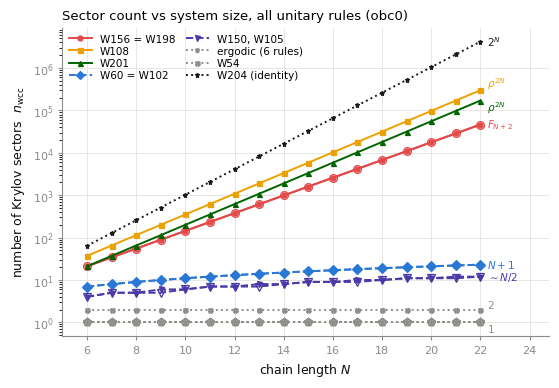

In [7]:
fig, ax = plt.subplots(figsize=(COL * 1.65, H1 * 1.45))
scaling_panel(ax, "n_recurrent",
              r"number of Krylov sectors  $n_{\mathrm{wcc}}$",
              title=f"Sector count vs system size, all unitary rules ({BC})")
fig.tight_layout()
save(fig, "fig_paper_sectors")
plt.show()

wrote figures/paper/fig_paper_dmax_obc0.pdf


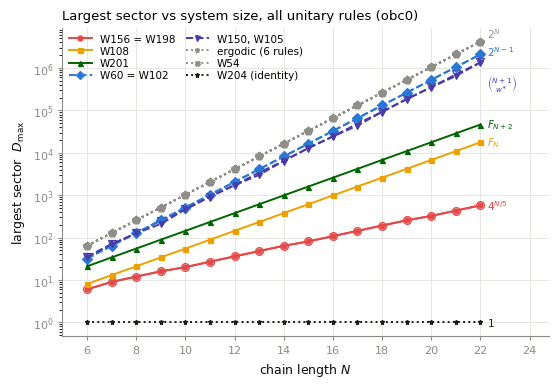

In [8]:
fig, ax = plt.subplots(figsize=(COL * 1.65, H1 * 1.45))
scaling_panel(ax, "d_max", r"largest sector  $D_{\max}$",
              title=f"Largest sector vs system size, all unitary rules ({BC})")
fig.tight_layout()
save(fig, "fig_paper_dmax")
plt.show()

### The two as one figure

The panels are complementary — a rule high in (a) is low in (b), which is the
$n_{\mathrm{wcc}} \cdot D_{\max} \ge 2^N$ constraint showing up as a mirror — so
a paper usually wants them side by side.

Eight entries do not fit inside a half-width panel without landing on a curve,
so here the legend goes underneath and is shared. `LEGEND_BELOW_NCOLS` in §2
sets how it wraps.

wrote figures/paper/fig_paper_scaling_obc0.pdf


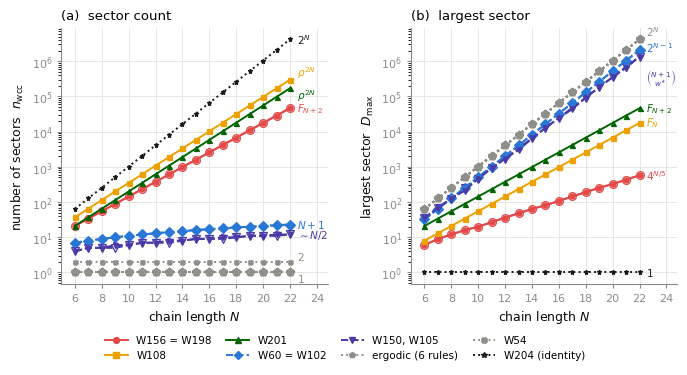

In [9]:
LEGEND_BELOW_NCOLS = 4

fig, axes = plt.subplots(1, 2, figsize=(WIDE, H1 * 1.34))
scaling_panel(axes[0], "n_recurrent",
              r"number of sectors  $n_{\mathrm{wcc}}$",
              title="(a)  sector count", legend=False)
scaling_panel(axes[1], "d_max",
              r"largest sector  $D_{\max}$",
              title="(b)  largest sector", legend=False)

handles, labels = [], []
for tr in TRACKS:
    nmax = _track_nmax(tr)
    lab = tr["label"]
    if N_RANGE_IN_LEGEND and nmax <= max(
            _track_nmax(t) for t in TRACKS) - N_RANGE_LEGEND_GAP:
        lab += f"  ($N\\leq{nmax}$)"
    handles.append(mpl.lines.Line2D([], [], color=tr["color"], ls=tr["ls"],
                                    marker=tr["marker"], ms=4.2, lw=1.4))
    labels.append(lab)
fig.tight_layout(w_pad=2.0, rect=(0, 0.06, 1, 1))
fig.legend(handles, labels, frameon=False, fontsize=FS_LEGEND,
           ncols=LEGEND_BELOW_NCOLS, loc="lower center",
           bbox_to_anchor=(0.5, -0.02), handlelength=2.2, columnspacing=1.4)
save(fig, "fig_paper_scaling")
plt.show()

## 7 · Figure 3 — the sector-size distribution of W156 and W108

The scaling figures separate the four classes but they do **not** separate the
two exponentially fragmented rules from each other in any interesting way: both
are straight lines with similar slopes. The size distribution does.

Two questions, one per row, for each rule:

* **(top) how many sectors are there of each size?** Log-spaced bins, log
  counts — the shape of the fragmentation.
* **(bottom) where does a *random* product state end up?** The cumulative
  fraction of Hilbert space carried by sectors of size $\le s$. Read the median
  sector size off at $y = 0.5$.

The second row is the operationally meaningful one: the *typical* sector is much
smaller than $D_{\max}$, and the two rules differ far more in the typical size
than in the largest.

$N$ is ordered, so it is drawn as a single-hue light→dark ramp rather than three
categorical colours. The dashed vertical rule marks $D_{\max}$ at the largest
$N$ shown. (The trivial classes are omitted here for the obvious reason: an
ergodic rule's distribution is one bar at $s=2^N$ and the identity's is one bar
at $s=1$. Put any rule in `HIST_RULES` and it will be drawn.)

wrote figures/paper/fig_paper_sizehist_obc0.pdf


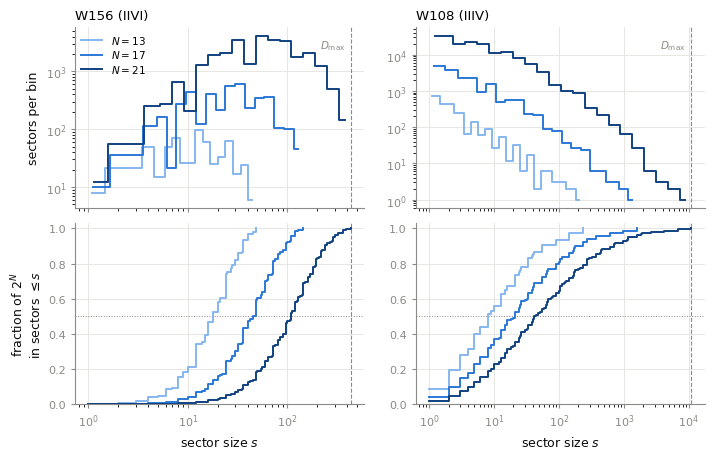

In [10]:
def hist_curves(rule, N, nbins=None):
    """Log-binned size distribution plus the exact cumulative-mass curve."""
    h = size_hist(rule, N)
    sizes = np.array(sorted(h), float)
    counts = np.array([h[int(s)] for s in sizes], float)

    edges = np.logspace(0, log10(sizes[-1]) + 1e-9, (nbins or HIST_BINS) + 1)
    idx = np.clip(np.digitize(sizes, edges) - 1, 0, len(edges) - 2)
    binned = np.zeros(len(edges) - 1)
    np.add.at(binned, idx, counts)
    centres = np.sqrt(edges[:-1] * edges[1:])

    mass = sizes * counts / 2.0 ** N          # fraction of Hilbert space
    return dict(centres=centres, binned=binned,
                sizes=sizes, cum=np.cumsum(mass),
                d_max=sizes[-1], n_sec=counts.sum(),
                mean=2.0 ** N / counts.sum())


fig, axes = plt.subplots(2, len(HIST_RULES),
                         figsize=(COL * 1.05 * len(HIST_RULES), HHIST * 2),
                         sharex="col")
axes = np.atleast_2d(axes)

for c, rule in enumerate(HIST_RULES):
    top, bot = axes[0, c], axes[1, c]
    panel_style(top)
    panel_style(bot)

    for k, N in enumerate(HIST_NS):
        col = HIST_RAMP[k % len(HIST_RAMP)]
        cu = hist_curves(rule, N)
        nz = cu["binned"] > 0
        top.step(cu["centres"][nz], cu["binned"][nz], where="mid",
                 color=col, lw=1.4, label=f"$N={N}$", zorder=3)
        bot.step(cu["sizes"], cu["cum"], where="post",
                 color=col, lw=1.4, label=f"$N={N}$", zorder=3)

    last = hist_curves(rule, HIST_NS[-1])
    for ax in (top, bot):
        ax.axvline(last["d_max"], color=MUTED, lw=0.8, ls="--", zorder=1)
        ax.set_xscale("log")
    top.annotate(r"$D_{\max}$", (last["d_max"], 1.0),
                 xycoords=("data", "axes fraction"),
                 textcoords="offset points", xytext=(-4, -8),
                 ha="right", va="top", fontsize=FS_ANNOT, color=MUTED)

    top.set_yscale("log")
    top.set_title(f"W{rule} ({''.join(rules_mod.wolfram_to_tuple(rule))})",
                  fontsize=FS_TITLE, loc="left")
    bot.set_ylim(0, 1.03)
    bot.set_xlabel("sector size $s$", fontsize=FS_LABEL)
    bot.axhline(0.5, color=MUTED, lw=0.7, ls=":", zorder=1)

    if c == 0:
        top.set_ylabel("sectors per bin", fontsize=FS_LABEL)
        bot.set_ylabel("fraction of $2^N$\nin sectors $\\leq s$",
                       fontsize=FS_LABEL)
        # upper LEFT: the D_max rule and its label own the top right corner
        top.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left",
                   labelspacing=0.25, borderpad=0.1)

fig.tight_layout(w_pad=1.6, h_pad=0.8)
save(fig, "fig_paper_sizehist")
plt.show()

### The numbers behind Figure 3

Worth quoting in a caption. $D_{\max}/2^N$ is the largest fraction of Hilbert
space any one sector holds; the median is the size of the sector a uniformly
random computational-basis state lands in.

In [11]:
# PF.size_stats is the same arithmetic, in the package, so the report table and
# this cell cannot disagree.
print(f"{'rule':>5} {'N':>3} {'sectors':>9} {'D_max':>8} {'D_max/2^N':>11}"
      f" {'mean':>8} {'median':>8} {'singletons':>11}")
for rule in HIST_RULES:
    for N in HIST_NS:
        s = PF.size_stats(rule, N, BC)
        print(f"{rule:>5} {N:>3} {s['n_sectors']:>9} {s['d_max']:>8}"
              f" {s['d_max_fraction']:>11.3e} {s['mean']:>8.2f}"
              f" {s['median']:>8} {s['n_singletons']:>11}")

 rule   N   sectors    D_max   D_max/2^N     mean   median  singletons
  156  13       610       48   5.859e-03    13.43       18           8
  156  17      4181      144   1.099e-03    31.35       45          10
  156  21     28657      432   2.060e-04    73.18      108          12
  108  13      1897      233   2.844e-02     4.32        8         714
  108  17     17991     1597   1.218e-02     7.29       21        4895
  108  21    170625    10946   5.219e-03    12.29       42       33552


## 8 · Figure 4 (optional) — the frozen states

A by-product of certifying the census: the number of size-1 sectors is an exact
law for **every** unitary rule too, and it is the sharpest single number for
telling the four classes apart at a glance.

* ergodic: $0$ (W54: exactly $1$, the all-zero state, which $r_{00}=I$ freezes)
* polynomial: $2$ for W60/W102; $1$ or $2$ by parity for W150; and for W105 the
  period-4 pattern $1,2,1,0$ — the $0$ falling at $N \equiv 1 \pmod 4$, the same
  residue class where W105 parts from W150 in both other series
* exponential: $\lfloor (N{+}1)/2 \rfloor + 1$ for W156/W198, and for W108 the
  **product** $F_{\lfloor N/2\rfloor+2} F_{\lceil N/2\rceil+2}$ — the frozen
  count factorises over the two sublattices, which is the same even/odd split
  that carries R18's two independent wall charges. W201 is the same product with
  the indices pulled down by one.
* frozen: $2^N$, every state

Set `DRAW_FROZEN_FIGURE = False` in §2 to skip it.

wrote figures/paper/fig_paper_frozen_obc0.pdf


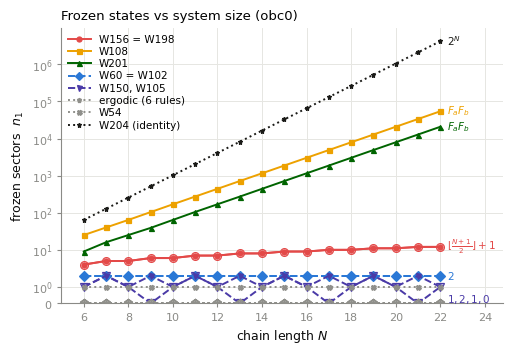

In [12]:
if DRAW_FROZEN_FIGURE:
    fig, ax = plt.subplots(figsize=(COL * 1.65, H1 * 1.3))
    scaling_panel(ax, "n_frozen", r"frozen sectors  $n_1$",
                  title=f"Frozen states vs system size ({BC})")
    ax.set_ylim(bottom=0)     # symlog: zero is a value here, not a gap
    save(fig, "fig_paper_frozen")
    plt.show()
else:
    print("skipped (DRAW_FROZEN_FIGURE = False)")

## 9 · Caveats

* **`obc0` only.** The `pbc` sweep is held pending caveats (`NEXT_STEPS.md`), and
  at odd $N$ under `pbc` the brick-wall layers stop commuting, so those points
  would need even $N$ only. This matters more than usual here: three of the four
  ergodic-vs-fragmented contrasts in §4 are *created* by the `obc0` vacuum, and
  under `pbc` the spin flip is restored and they would collapse onto their
  partners.
* **The tail of every rule comes from the flip reduction**, not from the sweep
  that produced the head: `extend_unitary` computed $N=17$–22 (18–22 for the
  rules the Tarjan sweep took further) by label propagation on the single-flip
  graph. That is a theorem for unitary rules and for no others, it is checked
  against the engine in `tests/test_flip_graph.py`, and the extension additionally
  reproduces every stored unit of a rule before adding to it. Records written
  this way carry `checks.source = "extend_unitary"`.
* **These are WCC sectors**, which for the unitary rules shown coincide with the
  strongly connected components, so the decomposition is exact for the monitored
  and the unmonitored chain alike. That equality is a property of *unitarity* and
  does not carry over to the dissipative rules — it is also what licenses merging
  the two sweeps in §3.
* **W198 is W156 under reflection**, and $\{57,99\}$, $\{60,102\}$,
  $\{153,195\}$ likewise — but every one of those eight rules was computed
  separately and is drawn from its own data (ring around dot), never mirrored
  from its partner, so a pair that ever stopped coinciding would show.
* **`sizes_recurrent` is truncated** at 2048 entries in the records for
  $N \ge 16$ (W108: $N \ge 14$). Figure 3 reads `size_hist`, which is not, and §3
  asserts the mass sums to $2^N$ so the distinction cannot be forgotten.
* **The law tags are exact, and §4 is what makes them so.** If a future sweep
  extends the $N$ range and a law breaks, §4 raises before any figure is drawn.